# Housing and Social Inequality
## Territorial Patterns in Ireland Using K-Means Clustering

Analyzed for study by Granades

## Load of the data set, cleaning and exploration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SAPS data set can be founded in:
https://www.cso.ie/en/census/census2022/census2022smallareapopulationstatistics/


In [2]:
df= pd.read_csv("SAPS_2022_Small_Area_UR_171024.csv", encoding="cp1252")

In [3]:
df.head(3)

,GUID,GEOGID,GEOGDESC,UR_Category,UR_Category_Desc,T1_1AGE0M,T1_1AGE1M,T1_1AGE2M,T1_1AGE3M,T1_1AGE4M,...,T15_1_2C,T15_1_3C,T15_1_GE4C,T15_1_NSC,T15_1_TC,T15_2_BB,T15_2_OIC,T15_2_NO,T15_2_NS,T15_2_T
0,4c07d11e-11d3-851d-e053-ca3ca8c0ca7f,017001001,017001001,4.0,4. Rural areas with high urban influence,0,6,1,1,0,...,71,20,6,7,135,80,37,9,9,135
1,4c07d11e-123a-851d-e053-ca3ca8c0ca7f,017002001,017002001,4.0,4. Rural areas with high urban influence,1,2,1,2,4,...,60,14,6,2,118,90,11,15,2,118
2,4c07d11e-14b1-851d-e053-ca3ca8c0ca7f,017002002,017002002,3.0,3. Independent urban towns,1,5,1,2,0,...,45,7,3,3,119,101,3,10,5,119


In [4]:
#Save original data frame
df_original= df.copy()

## Variable Selection

The following variables were selected based on their relevance for describing housing characteristics and urban density. These variables capture both structural attributes of properties and broader contextual information.

In [ ]:
# 1. % Flats (apartments)
df["pct_flats"] = df["T6_1_FA_H"] / (df["T6_1_FA_H"] + df["T6_1_HB_H"])

# 2. % Private rental
df["pct_private_rent"] = df["T6_3_RPLH"] / (
    df["T6_3_OMLH"] + df["T6_3_OOH"] + df["T6_3_RPLH"] + df["T6_3_RLAH"]
)

# 3. % Social rental (local authority
df["pct_social_rent"] = df["T6_3_RLAH"] / (
    df["T6_3_OMLH"] + df["T6_3_OOH"] + df["T6_3_RPLH"] + df["T6_3_RLAH"]
)

# 4. Vacancy rate
df["vacancy_rate"] = (df["T6_8_UHH"] + df["T6_8_OVD"]) / (
    df["T6_8_O"] + df["T6_8_UHH"] + df["T6_8_OVD"]
)

# 5. % Large households
df["pct_large_households"] = (
    df["T5_2_5PH"] + df["T5_2_6PH"] + df["T5_2_7PH"] + df["T5_2_GE8PH"]
) / df["T5_2_TH"]

# 6. % Small dwellings (1–2 bedrooms)
df["pct_small_units"] = (
    df["T6_9_0BRH"] + df["T6_9_1BRH"] + df["T6_9_2BRH"]
) / df["T6_9_TH"]

# 7. Overcrowding index = average persons per household / average bedrooms per dwelling
persons_avg = (
    df["T5_2_1PH"]*1 + df["T5_2_2PH"]*2 + df["T5_2_3PH"]*3 +
    df["T5_2_4PH"]*4 + df["T5_2_5PH"]*5 + df["T5_2_6PH"]*6 +
    df["T5_2_7PH"]*7 + df["T5_2_GE8PH"]*8
) / df["T5_2_TH"]

bedrooms_avg = (
    df["T6_9_0BRH"]*0 + df["T6_9_1BRH"]*1 + df["T6_9_2BRH"]*2 +
    df["T6_9_3BRH"]*3 + df["T6_9_4BRH"]*4 + df["T6_9_GE5BRH"]*5
) / df["T6_9_TH"]

df["overcrowding_index"] = persons_avg / bedrooms_avg

# 8. % low skill (semi-skilled + unskilled)
df["pct_low_skill"] = (df["T9_1_SST"] + df["T9_1_UST"]) / df["T9_1_TT"]

# 9. % high professional
df["pct_high_prof"] = df["T9_2_PA"] / df["T9_2_PT"]

# 10. % Early school leavers (completed education ≤17 years)
df["pct_early_leave"] = (
    df["T10_1_LT15T"] + df["T10_1_15T"] + df["T10_1_16T"] + df["T10_1_17T"]
) / df["T10_1_TT"]

# 11. % Extended education (≥21 years)
df["pct_high_education"] = df["T10_1_GE21T"] / df["T10_1_TT"]

print("Variables created from scratch")
df[["pct_flats","pct_private_rent","pct_social_rent","vacancy_rate"]].head()


Variables created from scratch


,pct_flats,pct_private_rent,pct_social_rent,vacancy_rate
0,0.000000,0.046875,0.007812,0.087838
1,0.008475,0.052632,0.008772,0.024793
2,0.008403,0.203540,0.035398,0.024590
3,0.044586,0.145833,0.013889,0.036810
4,0.000000,0.025974,0.012987,0.072165




## Building final dataset (df_final) with GEOGID + 12 features



In [6]:
features = [
    "pct_flats",
    "pct_private_rent",
    "pct_social_rent",
    "vacancy_rate",
    "pct_large_households",
    "pct_small_units",
    "overcrowding_index",
    "pct_low_skill",
    "pct_high_prof",
    "pct_early_leave",
    "pct_high_education"
]

df_final = df[["GEOGID"] + features].copy()

print("Shape df_final:", df_final.shape)
df_final.head()


Shape df_final: (18920, 12)


,GEOGID,pct_flats,pct_private_rent,pct_social_rent,vacancy_rate,pct_large_households,pct_small_units,overcrowding_index,pct_low_skill,pct_high_prof,pct_early_leave,pct_high_education
0,017001001,0.000000,0.046875,0.007812,0.087838,0.175182,0.066667,0.976340,0.126492,0.176334,0.234657,0.346570
1,017002001,0.008475,0.052632,0.008772,0.024793,0.169492,0.067797,0.823256,0.118841,0.162921,0.226721,0.352227
2,017002002,0.008403,0.203540,0.035398,0.024590,0.084034,0.058824,0.874680,0.130178,0.154971,0.219731,0.363229
3,017002003/01,0.044586,0.145833,0.013889,0.036810,0.101266,0.133758,0.821106,0.088838,0.203233,0.157895,0.355263
4,017003001,0.000000,0.025974,0.012987,0.072165,0.142857,0.122222,1.012466,0.129412,0.119691,0.188571,0.228571


In [7]:
# Final check on numeric coluns
X = df_final[features].copy()

# Change inf|-inf for NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Check for NaN rows
mask_valid = X.notna().all(axis=1)

df_clean = df_final[mask_valid].copy()

print("Total original rows:", len(df_final))
print("Cleaned rows (no NaN or inf):", len(df_clean))
df_clean.head()


Total original rows: 18920
Cleaned rows (no NaN or inf): 18916


,GEOGID,pct_flats,pct_private_rent,pct_social_rent,vacancy_rate,pct_large_households,pct_small_units,overcrowding_index,pct_low_skill,pct_high_prof,pct_early_leave,pct_high_education
0,017001001,0.000000,0.046875,0.007812,0.087838,0.175182,0.066667,0.976340,0.126492,0.176334,0.234657,0.346570
1,017002001,0.008475,0.052632,0.008772,0.024793,0.169492,0.067797,0.823256,0.118841,0.162921,0.226721,0.352227
2,017002002,0.008403,0.203540,0.035398,0.024590,0.084034,0.058824,0.874680,0.130178,0.154971,0.219731,0.363229
3,017002003/01,0.044586,0.145833,0.013889,0.036810,0.101266,0.133758,0.821106,0.088838,0.203233,0.157895,0.355263
4,017003001,0.000000,0.025974,0.012987,0.072165,0.142857,0.122222,1.012466,0.129412,0.119691,0.188571,0.228571


## Exploratory Data Analysis (EDA)

An exploratory data analysis was conducted to better understand the distribution and relationships between the selected variables. This step helps identify potential patterns, skewness, and outliers before applying more advanced techniques.

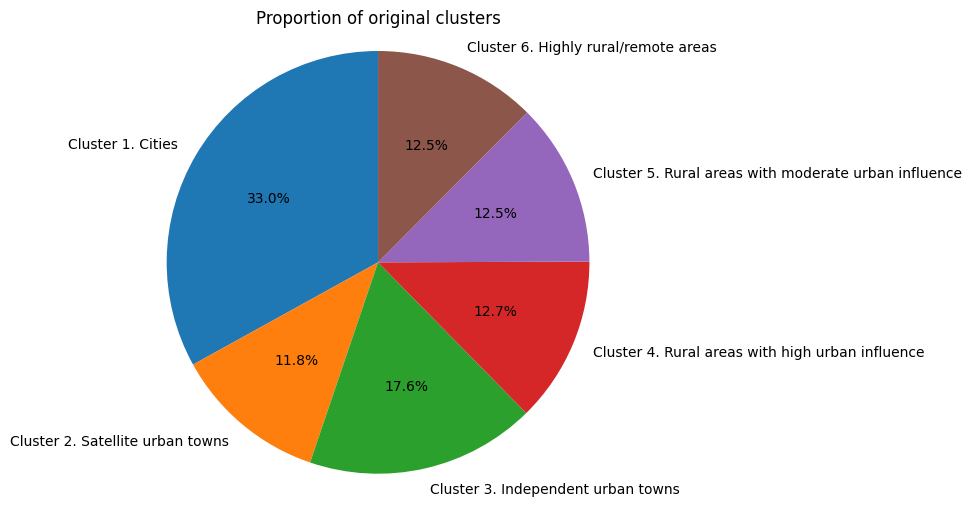

In [8]:
# Count observations per cluster
cluster_counts = df_original["UR_Category_Desc"].value_counts().sort_index()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    cluster_counts.values,
    labels=[f"Cluster {c}" for c in cluster_counts.index],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proportion of original clusters")
plt.axis("equal")
plt.show()

Figure above shows the distribution of the origanial, or proposed clusters by the census.

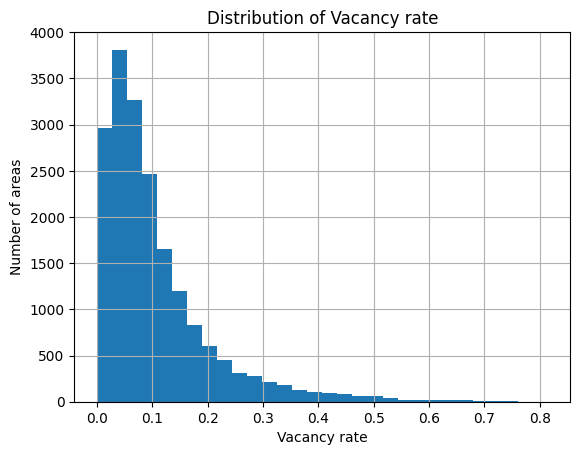

In [9]:
import matplotlib.pyplot as plt

df_clean["vacancy_rate"].hist(bins=30)
plt.xlabel("Vacancy rate")
plt.ylabel("Number of areas")
plt.title("Distribution of Vacancy rate")
plt.show()

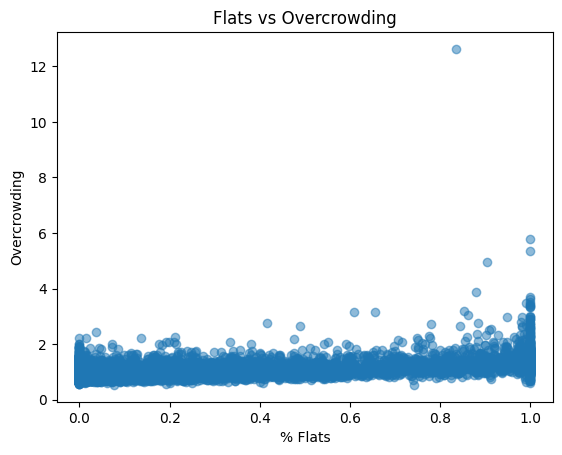

In [10]:
plt.scatter(
    df_clean["pct_flats"],
    df_clean["overcrowding_index"],
    alpha=0.5
)
plt.xlabel("% Flats")
plt.ylabel("Overcrowding")
plt.title("Flats vs Overcrowding")
plt.show()

The observed relationship suggests that areas with a higher proportion of flats tend to present higher levels of overcrowding, which is consistent with higher population density and smaller dwelling sizes.

## Feature Scaling

Since the selected variables are measured on different scales, standardization was applied to ensure that no single variable dominates the clustering process due to its magnitude.

In [11]:
from sklearn.preprocessing import StandardScaler

X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)


Scaled shape: (18916, 11)


## Elbow Method

The Elbow Method was used to determine an appropriate number of clusters for the K-means algorithm. This method evaluates how the within-cluster sum of squares changes as the number of clusters increases.

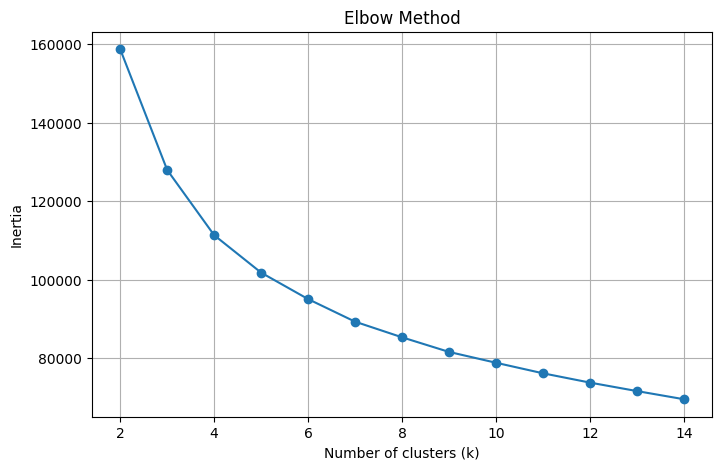

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(2, 15)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


Based on the elbow plot, a value of k = 4 was selected, as it represents a reasonable trade-off between model complexity and explanatory power.

## K-Means Clustering

Once the optimal number of clusters was selected, the K-means algorithm was applied to the standardized data in order to group areas with similar characteristics.

In [13]:
k = 4

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clusters = df_clean.copy()
df_clusters["cluster_kmeans"] = clusters

df_clusters.head()


,GEOGID,pct_flats,pct_private_rent,pct_social_rent,vacancy_rate,pct_large_households,pct_small_units,overcrowding_index,pct_low_skill,pct_high_prof,pct_early_leave,pct_high_education,cluster_kmeans
0,017001001,0.000000,0.046875,0.007812,0.087838,0.175182,0.066667,0.976340,0.126492,0.176334,0.234657,0.346570,3
1,017002001,0.008475,0.052632,0.008772,0.024793,0.169492,0.067797,0.823256,0.118841,0.162921,0.226721,0.352227,3
2,017002002,0.008403,0.203540,0.035398,0.024590,0.084034,0.058824,0.874680,0.130178,0.154971,0.219731,0.363229,3
3,017002003/01,0.044586,0.145833,0.013889,0.036810,0.101266,0.133758,0.821106,0.088838,0.203233,0.157895,0.355263,3
4,017003001,0.000000,0.025974,0.012987,0.072165,0.142857,0.122222,1.012466,0.129412,0.119691,0.188571,0.228571,0


Each observation was assigned to one of the four clusters, allowing further analysis of their internal composition and average profiles.

To make the comparison, orignal clusters are added back to the data set.

In [14]:
df_clusters["cluster_original"] = df_original.loc[df_clusters.index, "UR_Category_Desc"]
df_clusters.head()

,GEOGID,pct_flats,pct_private_rent,pct_social_rent,vacancy_rate,pct_large_households,pct_small_units,overcrowding_index,pct_low_skill,pct_high_prof,pct_early_leave,pct_high_education,cluster_kmeans,cluster_original
0,017001001,0.000000,0.046875,0.007812,0.087838,0.175182,0.066667,0.976340,0.126492,0.176334,0.234657,0.346570,3,4. Rural areas with high urban influence
1,017002001,0.008475,0.052632,0.008772,0.024793,0.169492,0.067797,0.823256,0.118841,0.162921,0.226721,0.352227,3,4. Rural areas with high urban influence
2,017002002,0.008403,0.203540,0.035398,0.024590,0.084034,0.058824,0.874680,0.130178,0.154971,0.219731,0.363229,3,3. Independent urban towns
3,017002003/01,0.044586,0.145833,0.013889,0.036810,0.101266,0.133758,0.821106,0.088838,0.203233,0.157895,0.355263,3,4. Rural areas with high urban influence
4,017003001,0.000000,0.025974,0.012987,0.072165,0.142857,0.122222,1.012466,0.129412,0.119691,0.188571,0.228571,0,5. Rural areas with moderate urban influence


# Cluster Profiling

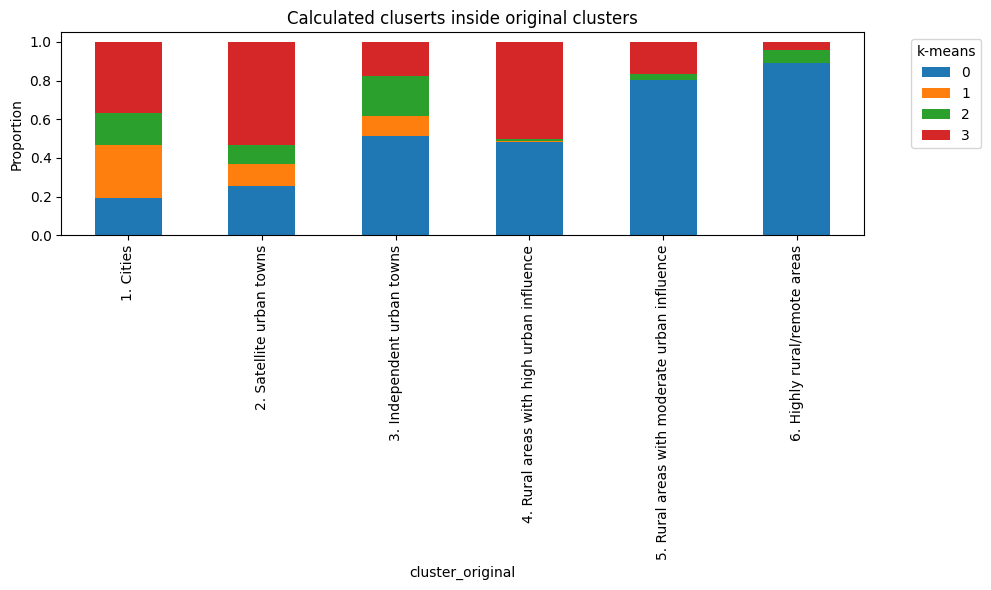

In [15]:
pd.crosstab(
    df_clusters["cluster_original"],
    df_clusters["cluster_kmeans"],
    normalize="index"
).plot(kind="bar", stacked=True, figsize=(10,6))

plt.ylabel("Proportion")
plt.title("Calculated cluserts inside original clusters")
plt.legend(title="k-means", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

These profiles provide insight into how the clusters differ in terms of housing structure, density, and overcrowding levels.

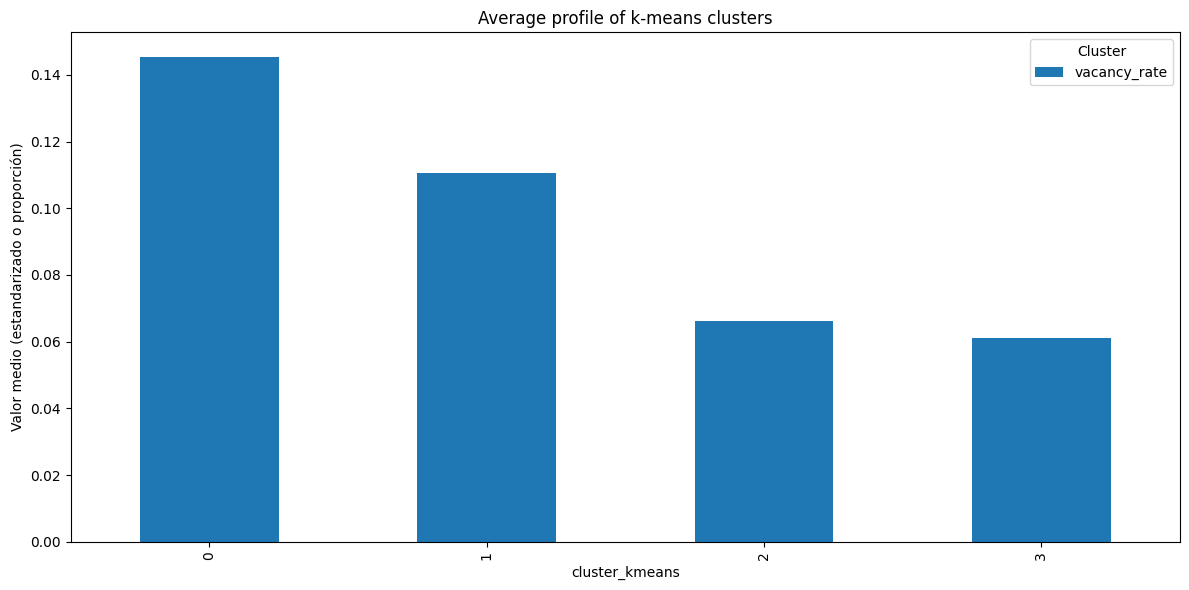

In [16]:
cluster_profile = df_clusters.groupby("cluster_kmeans")["vacancy_rate"].mean()

cluster_profile.T.plot(kind="bar", figsize=(12,6))
plt.title("Average profile of k-means clusters")
plt.ylabel("Valor medio (estandarizado o proporción)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Comparison of values between clusters

pct_flats - pct_private_rent - vacancy_rate - overcrowding_index - pct_low_skill - pct_high_prof


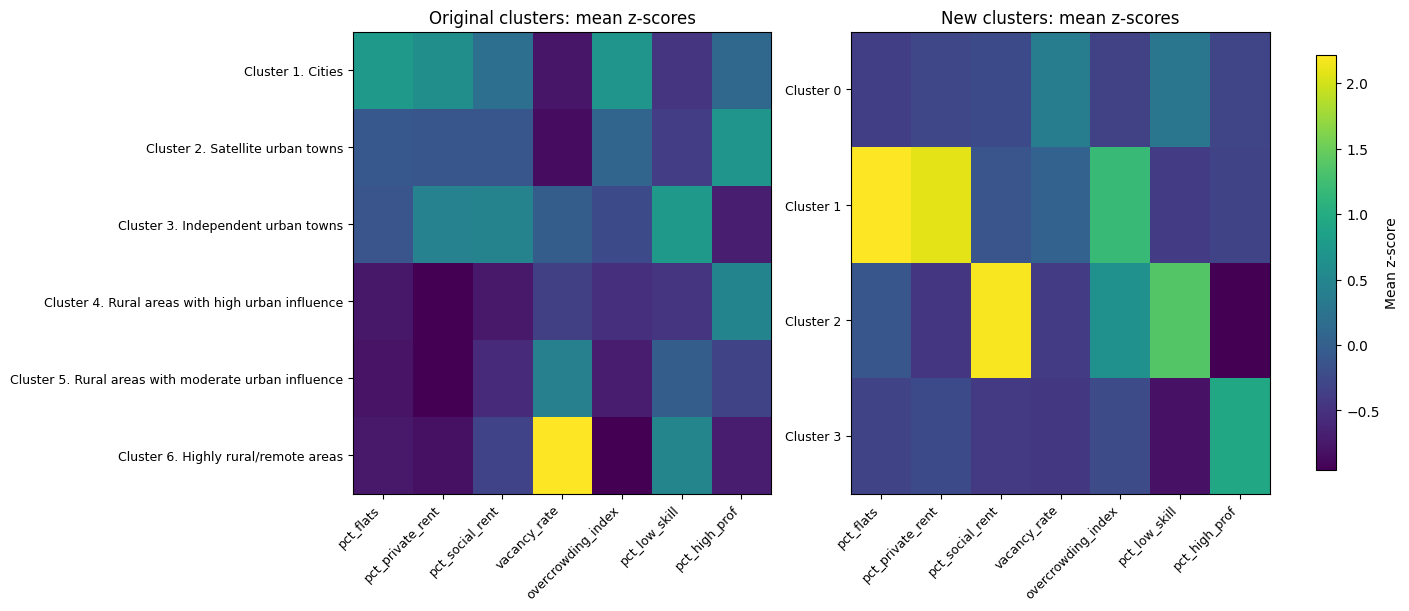

In [17]:
strong_vars = ["pct_flats","pct_private_rent","pct_social_rent","vacancy_rate","overcrowding_index","pct_low_skill","pct_high_prof"]

# Calculate z-score of each selected variable
Z = (df_clusters[strong_vars] - df_clusters[strong_vars].mean()) / df_clusters[strong_vars].std(ddof=0)
df_hm_z = df_clusters[["cluster_kmeans", "cluster_original"]].join(Z)

# mean profiles
prof_orig = df_hm_z.groupby("cluster_original")[strong_vars].mean()
prof_new  = df_hm_z.groupby("cluster_kmeans")[strong_vars].mean()

def plot_heatmap(ax, mat, title):
    im = ax.imshow(mat.values, aspect="auto")
    ax.set_title(title, fontsize=12)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([f"Cluster {i}" for i in mat.index], fontsize=9)
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im1 = plot_heatmap(axes[0], prof_orig, "Original clusters: mean z-scores")
im2 = plot_heatmap(axes[1], prof_new,  "New clusters: mean z-scores")

cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("Mean z-score", rotation=90)

plt.show()

/tmp/ipython-input-1303948358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


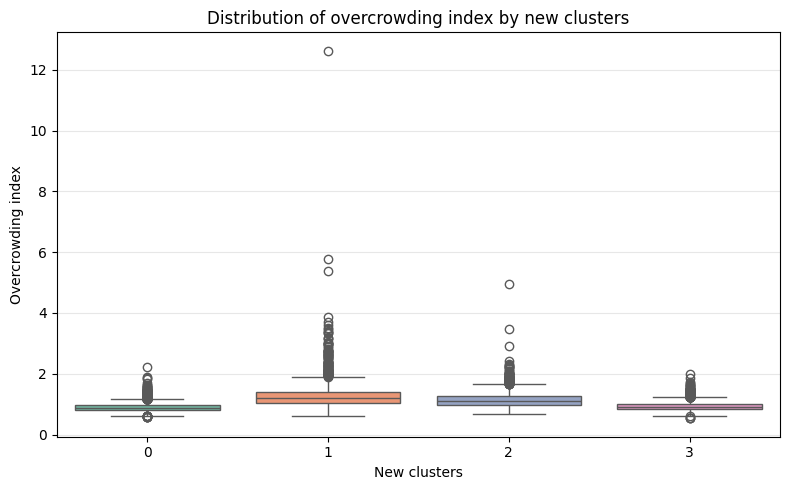

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clusters,
    x="cluster_kmeans",
    y="overcrowding_index",
    palette="Set2"
)

plt.xlabel("New clusters")
plt.ylabel("Overcrowding index")
plt.title("Distribution of overcrowding index by new clusters")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2842856159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


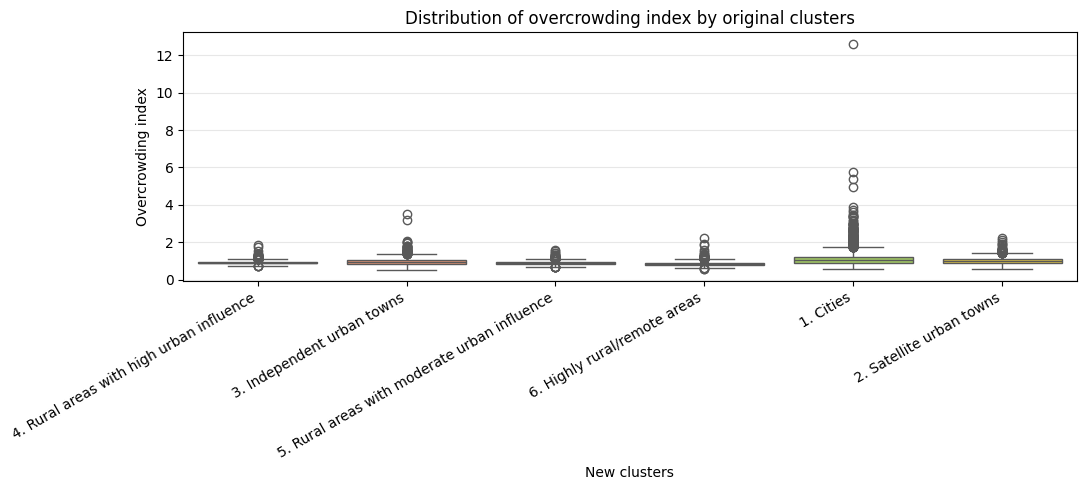

In [19]:
plt.figure(figsize=(11, 5))
sns.boxplot(
    data=df_clusters,
    x="cluster_original",
    y="overcrowding_index",
    palette="Set2"
)

plt.xlabel("New clusters")
plt.ylabel("Overcrowding index")
plt.title("Distribution of overcrowding index by original clusters")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()